In [1]:
!pip install teneto --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.1/229.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 708.5/708.5 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 6.4 MB/s eta 0:00:00


##[Bibliografía de Teneto](https://teneto.readthedocs.io/_/downloads/en/stable/pdf/)

In [7]:
import numpy as np
from teneto import TemporalNetwork

tnet = TemporalNetwork()

np.random.seed(2019)
#3 nodos, 2 tiempos, 0.5 probabilidad de enlazarse
tnet.generatenetwork('rand_binomial',size=(3,2), prob=0.5)
tnet.network

array([[[0., 0.],
        [1., 1.],
        [1., 0.]],

       [[1., 1.],
        [0., 0.],
        [0., 0.]],

       [[1., 0.],
        [0., 0.],
        [0., 0.]]])

No hay lazo del nodo 0 a si mismo en t=0 ni t=1

In [12]:
            #n_1,n_2,t
tnet.network[0, 0, :]

array([0., 0.])

Hay una arista del nodo 0 al nodo 1 en el tiempo t=0 y en t=1

In [21]:
tnet.network[0, 1, :]

array([1., 1.])

Hay una arista del nodo 0 al nodo 2 en t=0, pero no en t=1

In [20]:
tnet.network[0, 2, :]

array([1., 0.])

In [13]:
import pandas as pd
import numpy as np

#Convertimos el array 3D de numpy a un DataFrame de lista de aristas
nodes, _, times = tnet.network.shape

#Creamos una lista vacía para almacenar las aristas
edges = []
#Iteramos a través del tiempo, nodos fuente y nodos destino
for t_idx in range(times):
    for i_idx in range(nodes):
        for j_idx in range(nodes):
            weight = tnet.network[i_idx, j_idx, t_idx]
            #Solo añadimos aristas con un peso
            if weight != 0:
                edges.append({'i': i_idx, 'j': j_idx, 't': t_idx, 'weight': weight})

network_df = pd.DataFrame(edges)
display(network_df.head(10))

,i,j,t,weight
0,0,1,0,1.0
1,0,2,0,1.0
2,1,0,0,1.0
3,2,0,0,1.0
4,0,1,1,1.0
5,1,0,1,1.0


In [16]:
network_df.shape

(6, 4)

Puedes inspeccionar diferentes partes de la red llamando a `tnet.get_network_when()` y especificando un argumento i, j o t.

In [17]:
tnet.get_network_when(i=1)

,i,j,t,weight
0,1,0,0,1.0
1,1,0,1,1.0


In [35]:
tnet.get_network_when(i=1, j=1, logic='or') #o and

,i,j,t,weight
0,0,1,0,0.50
1,0,1,1,0.75


In [19]:
tnet.get_network_when(i=1, t=0)

,i,j,t,weight
0,1,0,0,1.0


## Tipos de redes
bu, bd, wu, wd

b: binaria, pesos 0 o 1

w: con pesos

u: no dirigida

d: dirigida

In [26]:
np.random.seed(2019)
#Redes siguiendo cualquier distribución teórica
G = np.random.beta(1, 1, [3,3,2]) #3 nodos 2 tiempos
#diagonal: Si es False se eliminan los lazos                #PROBAR EN CLASE
tnet = TemporalNetwork(from_array=G, nettype='wd', diagonal=True)
tnet.network

array([[[0.62881997, 0.05908437],
        [0.83397431, 0.85650926],
        [0.51867029, 0.37095074]],

       [[0.67342242, 0.53977806],
        [0.78089779, 0.44724686],
        [0.52269736, 0.04666516]],

       [[0.54242292, 0.60766971],
        [0.43190771, 0.60123545],
        [0.53591418, 0.30817286]]])

In [27]:
def network_df(network):
  nodes, _, times = tnet.network.shape
  edges = []

  for t_idx in range(times):
      for i_idx in range(nodes):
          for j_idx in range(nodes):
              weight = tnet.network[i_idx, j_idx, t_idx]
              if weight != 0:
                  edges.append({'i': i_idx, 'j': j_idx, 't': t_idx, 'weight': weight})

  network_df = pd.DataFrame(edges)
  display(network_df.head(10))

In [28]:
network_df(tnet.network)

,i,j,t,weight
0,0,0,0,0.628820
1,0,1,0,0.833974
2,0,2,0,0.518670
3,1,0,0,0.673422
4,1,1,0,0.780898
5,1,2,0,0.522697
6,2,0,0,0.542423
7,2,1,0,0.431908
8,2,2,0,0.535914
9,0,0,1,0.059084


In [29]:
#3 nodos y 2 tiempos
tnet.netshape

(3, 2)

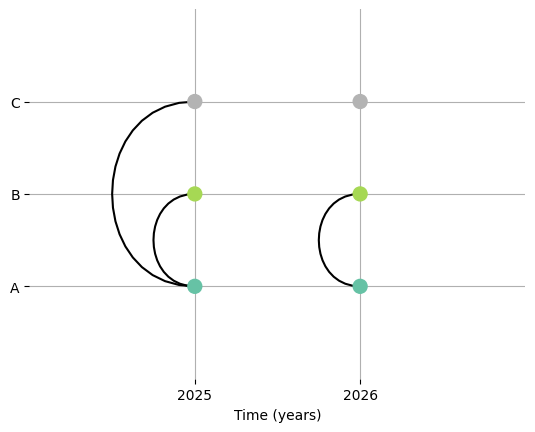

In [30]:
import matplotlib.pyplot as plt

#etiquetas de tiempo
tlabs = ['2025','2026']
#unidades de tiempo
tunit = 'years'

#etiquetas de nodos
nlabs = ['A', 'B', 'C']
#nodos, tipo de unidad temporal, etiqueta del tiempo, tipo de red (binaria no dirigida)s
tnet = TemporalNetwork(nodelabels=nlabs, timeunit=tunit, timelabels=tlabs,nettype='bu')

np.random.seed(2019)
tnet.generatenetwork('rand_binomial',size=(3,2), prob=0.5)
tnet.plot('slice_plot', cmap='Set2')
plt.show()

## Construcción de Redes

### DataFrame

In [31]:
netin = {'i': [0,0,1,1],
         'j': [1,2,2,2],
         't': [0,0,0,1],
         'weight': [0.5,0.75,0.25,1]}
df = pd.DataFrame(data=netin)
tnet = TemporalNetwork(from_df=df)
tnet.network

/usr/local/lib/python3.12/dist-packages/teneto/classes/network.py:242: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.network['i'] = self.network['i'].astype(int)
/usr/local/lib/python3.12/dist-packages/teneto/classes/network.py:243: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.network['j'] = self.network['j'].astype(int)


,i,j,t
0,0,1,0
1,0,2,0
2,1,2,0
3,1,2,1


### Lista de enlaces

In [32]:
            #n1,n2,t,w
edgelist = [[0,1,0,0.5],
            [0,1,1,0.75]]
tnet = TemporalNetwork(from_edgelist=edgelist)
tnet.network

,i,j,t,weight
0,0,1,0,0.50
1,0,1,1,0.75


## Métricas
Con el módulo `teneto.networkmeasures`

Varias tienen una versión global y una por comunidades

`calc=’global’ `
`calc=’communities’ `

### Métricas de Centralidad

Las medidas de centralidad cuantifican un valor por nodo.

* `temporal_degree_centrality()`
* `temporal_betweenness_centrality()`
* `temporal_closeness_centrality()`
* `topological_overlap()`
* `bursty_coeff()`

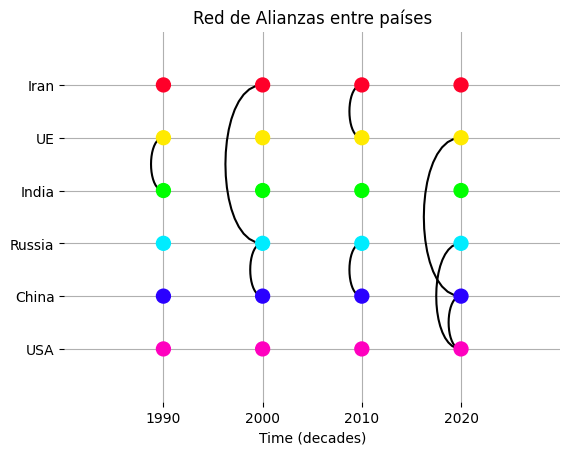

In [48]:
#Etiquetas de tiempo
tlabs_decades = ['1990', '2000', '2010', '2020']
tunit_decades = 'decades'

nlabs_countries = [
    'USA', 'China', 'Russia', 'India', 'UE', 'Iran'
]

#Red Temporal
metric_tnet = TemporalNetwork(
    nodelabels=nlabs_countries,
    timeunit=tunit_decades,
    timelabels=tlabs_decades,
    nettype='bu' #Ambos tienen una relacion de amistad a la vez
)

np.random.seed(42)

#Generar la red: 10 nodos (países), 4 tiempos (décadas), probabilidad de conflicto 0.15
metric_tnet.generatenetwork('rand_binomial',
                            size=(len(nlabs_countries),
                            len(tlabs_decades)),
                            prob=0.15)

metric_tnet.plot('slice_plot', cmap='gist_rainbow_r')
plt.title('Red de Alianzas entre países')
plt.show()

In [43]:
metric_tnet.netshape

(6, 4)

$D_{i} = \sum_t\sum_j A_{ijt}$

$D_{it} = \sum_j A_{ijt}$

In [44]:
import teneto.networkmeasures as tnm
#Centralidad de grado temporal: temporal_degree_centrality()
degree_centrality = tnm.temporal_degree_centrality(metric_tnet, calc='global')
display(pd.DataFrame(degree_centrality, index=metric_tnet.nodelabels, columns=['Centralidad de Grado']))

,Centralidad de Grado
USA,2.0
China,4.0
Russia,4.0
India,1.0
UE,3.0
Iran,2.0


$B_{it} = {1 \over (N-1)(N-2)} \sum_{j = 1; j \neq i}
\sum_{k = 1; k \neq i,j} {\sigma^i_{jkt} \over \sigma_{jk}}$

In [53]:
#Matriz de N nodos x T tiempos
betweenness_centrality = tnm.temporal_betweenness_centrality(metric_tnet, calc='global')

#Creamos nombres para las columnas (t1, t2, t3, t4...), asume que el num_columnas coincide con la dim_1 de la matriz
n_tiempos = betweenness_centrality.shape[1]
columnas_t = [f'Tiempo {t+1}' for t in range(n_tiempos)]

print(f"\n--- Centralidad Intermedia Temporal ---")
#Filas = Nodos (i), Columnas = Tiempos (t)
df_temporal = pd.DataFrame(
    betweenness_centrality,
    index=metric_tnet.nodelabels,
    columns=columnas_t
)
display(df_temporal)


--- Centralidad Intermedia Temporal ---


,Tiempo 1,Tiempo 2,Tiempo 3,Tiempo 4
USA,0.000000,0.000000,0.000000,0.0250
China,0.116667,0.066667,0.108333,0.0750
Russia,0.100000,0.100000,0.025000,0.0250
India,0.000000,0.000000,0.000000,0.0000
UE,0.162500,0.062500,0.112500,0.0625
Iran,0.050000,0.050000,0.012500,0.0000


$\begin{split}C^T_{i} = {{1} \over {N-1}}\sum_j{1\over \tau_{ij}}\end{split}$

In [56]:
#Temporal_closeness_centrality()
closeness_centrality = tnm.temporal_closeness_centrality(metric_tnet)
display(pd.DataFrame(closeness_centrality, index=metric_tnet.nodelabels, columns=['Centralidad de Cercanía']))

/usr/local/lib/python3.12/dist-packages/teneto/networkmeasures/temporal_closeness_centrality.py:76: RuntimeWarning: Mean of empty slice
  closeness = np.nansum(1 / np.nanmean(pathmat, axis=2),


,Centralidad de Cercanía
USA,1.000000
China,0.880000
Russia,0.600000
India,0.746667
UE,0.746667
Iran,0.456667


El solapamiento topológico (topological overlap) cuantifica la persistencia de las aristas a lo largo del tiempo.

Si dos puntos de tiempo consecutivos tienen aristas similares, este valor es alto (máximo 1).
Si hay mucho cambio, el valor se aproxima a 0.

* Por tiempo: $TopoOverlap_{i,t} = {\sum_j G_{i,j,t} G_{i,j,t+1}
\over \sqrt{\sum_j G_{i,j,t} \sum_j G_{i,j,t+1}}}$
* Por nodo: $AvgTopoOverlap_{i} = {1 \over T-1} \sum_t TopoOverlap_{i,t}$

In [58]:
#topological_overlap()
topological_overlap = tnm.topological_overlap(metric_tnet, calc='pertime')
display(pd.DataFrame(topological_overlap, index=metric_tnet.nodelabels))

topological_overlap = tnm.topological_overlap(metric_tnet, calc='node')
display(pd.DataFrame(topological_overlap, index=metric_tnet.nodelabels))

/usr/local/lib/python3.12/dist-packages/teneto/networkmeasures/topological_overlap.py:143: RuntimeWarning: invalid value encountered in divide
  topo_overlap = numerator / denominator


,0,1,2,3
USA,0.0,0.000000,0.0,NaN
China,0.0,1.000000,0.0,NaN
Russia,0.0,0.707107,0.0,NaN
India,0.0,0.000000,0.0,NaN
UE,0.0,0.000000,0.0,NaN
Iran,0.0,0.000000,0.0,NaN


/usr/local/lib/python3.12/dist-packages/teneto/networkmeasures/topological_overlap.py:143: RuntimeWarning: invalid value encountered in divide
  topo_overlap = numerator / denominator


,0
USA,0.000000
China,0.333333
Russia,0.235702
India,0.000000
UE,0.000000
Iran,0.000000


China es la que mas tiene pues mantiene un enlace con Rusia durante 2 décadas.

El **coeficiente de explosividad (burstiness coefficient, B)** mide qué tan **irregular o concentrada en ráfagas** es la ocurrencia de eventos en el tiempo (por ejemplo, contactos o interacciones en una red temporal).

Se define como:

$
B = \frac{\sigma_{ICT} - \mu_{ICT}}{\sigma_{ICT} + \mu_{ICT}}
$

donde:  
- $\mu_{ICT} $: **media** de los tiempos entre contactos (*inter-contact times*).  
- $\sigma_{ICT}$: **desviación estándar** de los tiempos entre contactos.

---

### Interpretación:
- **B > 0** → comportamiento **explosivo o “bursty”**: los contactos ocurren en ráfagas cortas, seguidas de largos periodos sin actividad.  
  *Ejemplo:* interacciones en redes sociales o correos electrónicos (varios mensajes seguidos y luego silencio).  
- **B = 0** → comportamiento **aleatorio**: los contactos siguen una distribución exponencial, como un proceso de Poisson.  
  *Ejemplo:* llamadas telefónicas aleatorias a lo largo del día.  
- **B < 0** → comportamiento **periódico o regular**: los contactos ocurren a intervalos casi constantes.  
  *Ejemplo:* sensores que se comunican cada 10 segundos o una persona que revisa el correo a horas fijas.

---


In [60]:
bursty_coeff_matrix = tnm.bursty_coeff(metric_tnet)
bursty_coeff_matrix

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:218: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:175: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:210: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


array([[nan, nan, nan, nan, nan, nan],
       [nan, nan, -1., nan, nan, nan],
       [nan, -1., nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan, nan]])

La mayoria de relaciones son regulares o inexistentes